<a href="https://colab.research.google.com/github/trewto/Machine-Learning-Models/blob/main/ForcastWeather_Predict21Aug24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

**Function of plotting graph**



In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y, p_type=2):
    """
    Evaluates the given model on training and testing data, and plots the results.

    Parameters:
    - model: Trained model to evaluate
    - X_train_scaled: Scaled training features
    - X_test_scaled: Scaled testing features
    - y_train: Training target values
    - y_test: Testing target values
    - scaler_y: Scaler used to scale the target values
    """
    # Predict
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    #


    # Inverse transform the predictions
    y_pred_train = scaler_y.inverse_transform(y_pred_train.reshape(-1, 1))
    y_pred_test = scaler_y.inverse_transform(y_pred_test.reshape(-1, 1))

    negative_count_test = np.sum(y_pred_test < 0)
    negative_count_train = np.sum(y_pred_train < 0)

    print(f'Number of negative values in y_pred_test: {negative_count_test} and in train {negative_count_train}')
    y_pred_test = np.clip(y_pred_test, a_min=0, a_max=None)

    y_pred_train = np.clip(y_pred_train, a_min=0, a_max=None)

    negative_count_test = np.sum(y_pred_test < 0)
    negative_count_train = np.sum(y_pred_train < 0)

    print(f'Number of negative values after in y_pred_test: {negative_count_test} and in train {negative_count_train}')



    # Calculate metrics
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    # Print metrics
    print(f'Training MSE: {mse_train:.2f}, Training MAE: {mae_train:.2f}')
    print(f'Testing MSE: {mse_test:.2f}, Testing MAE: {mae_test:.2f}')

    if p_type == 1:
      # Plot predictions vs actual values (Testing set)
      plt.figure(figsize=(12, 6))
      plt.plot(y_test.values, label='Actual')
      plt.plot(y_pred_test, label='Predicted')
      plt.legend()
      plt.title('Actual vs Predicted Precipitation (Testing Set)')
      plt.xlabel('Sample Index')
      plt.ylabel('Precipitation')
      plt.show()

      # Plot predictions vs actual values (Training set)
      plt.figure(figsize=(6, 3))
      plt.plot(y_train.values, label='Actual')
      plt.plot(y_pred_train, label='Predicted')
      plt.legend()
      plt.title('Actual vs Predicted Precipitation (Training Set)')
      plt.xlabel('Sample Index')
      plt.ylabel('Precipitation')
      plt.show()
    elif p_type == 2:
    # Plot predictions vs actual values (Testing set) as bar diagram
      plt.figure(figsize=(6, 3))
      plt.bar(np.arange(len(y_test)), y_test.values.flatten(), label='Actual', alpha=0.6)
      plt.bar(np.arange(len(y_pred_test)), y_pred_test.flatten(), label='Predicted', alpha=0.6)
      plt.legend()
      plt.title('Actual vs Predicted Precipitation (Testing Set)')
      plt.xlabel('Sample Index')
      plt.ylabel('Precipitation')
      plt.show()

      # Plot predictions vs actual values (Training set) as bar diagram
      plt.figure(figsize=(6, 3))
      plt.bar(np.arange(len(y_train)), y_train.values.flatten(), label='Actual', alpha=0.6)
      plt.bar(np.arange(len(y_pred_train)), y_pred_train.flatten(), label='Predicted', alpha=0.6)
      plt.legend()
      plt.title('Actual vs Predicted Precipitation (Training Set)')
      plt.xlabel('Sample Index')
      plt.ylabel('Precipitation')
      plt.show()


Reading database

In [3]:
#df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2222.csv')
df = pd.read_csv('/content/drive/MyDrive/Projects/Weather/data_set_2.csv')


In [4]:
df.replace(-999, np.nan, inplace=True)

In [5]:
df.fillna(df.mean(), inplace=True)

In [6]:
print((df == -999).sum())


YEAR                   0
MO                     0
DY                     0
HR                     0
T2M                    0
T2MDEW                 0
T2MWET                 0
QV2M                   0
RH2M                   0
PRECTOTCORR            0
PS                     0
WS2M                   0
WD2M                   0
WS10M                  0
WD10M                  0
ALLSKY_SFC_UV_INDEX    0
dtype: int64


In [7]:
df.head()

,YEAR,MO,DY,HR,T2M,T2MDEW,T2MWET,QV2M,RH2M,PRECTOTCORR,PS,WS2M,WD2M,WS10M,WD10M,ALLSKY_SFC_UV_INDEX
0,2022,1,1,0,14.28,13.73,14.01,9.64,96.38,0.0,101.92,2.17,329.74,3.51,329.67,0.0
1,2022,1,1,1,13.83,13.71,13.77,9.64,99.06,0.0,101.91,2.26,331.75,3.57,331.75,0.0
2,2022,1,1,2,13.44,13.69,13.56,9.58,100.00,0.0,101.89,2.29,333.26,3.57,333.04,0.0
3,2022,1,1,3,13.21,13.65,13.44,9.58,100.00,0.0,101.87,2.23,333.79,3.46,333.72,0.0
4,2022,1,1,4,12.98,13.61,13.30,9.58,100.00,0.0,101.86,1.99,334.44,3.18,334.38,0.0


In [ ]:
#df.fillna(df.mean(), inplace=True)

In [25]:
# Create lagged features
prev = 6
def create_lagged_features(df, lag=5):
  df_lagged = df.copy()
  for i in range(prev, lag + 1):
      df_lagged[f'HR_lag{i}'] = df_lagged['HR'].shift(i)
      df_lagged[f'T2M_lag{i}'] = df_lagged['T2M'].shift(i)
      df_lagged[f'T2MDEW_lag{i}'] = df_lagged['T2MDEW'].shift(i)
      df_lagged[f'T2MWET_lag{i}'] = df_lagged['T2MWET'].shift(i)
      df_lagged[f'RH2M_lag{i}'] = df_lagged['RH2M'].shift(i)
      df_lagged[f'PS_lag{i}'] = df_lagged['PS'].shift(i)
      df_lagged[f'WS2M_lag{i}'] = df_lagged['WS2M'].shift(i)
      df_lagged[f'PRECTOTCORR_lag{i}'] = df_lagged['WD2M'].shift(i)
  df_lagged.dropna(inplace=True)
  return df_lagged

In [30]:
#l-prev hours of data for train
# l hour later prediction

l = 12

df_lagged = create_lagged_features(df, lag=l-1)

# Feature engineering
df_lagged['T2M*QV2M'] = df_lagged['T2M'] * df_lagged['QV2M']
df_lagged['T2M^2'] = df_lagged['T2M'] ** 2
df_lagged['QV2M^2'] = df_lagged['QV2M'] ** 2

lagged_features = [f'T2M_lag{i}' for i in range(prev, l)] + \
                      [f'T2MDEW_lag{i}' for i in range(prev, l)] + \
                      [f'T2MWET_lag{i}' for i in range(prev, l)] + \
                      [f'RH2M_lag{i}' for i in range(prev, l)] + \
                      [f'PS_lag{i}' for i in range(prev, l)] + \
                      [f'WS2M_lag{i}' for i in range(prev, l)]# + \
                     # [f'PRECTOTCORR_lag{i}' for i in range(1, l)]
                       #  [f'HR_lag{i}' for i in range(prev, l)] + \


#features = ['MO', 'DY', 'HR', 'T2M', 'QV2M', 'PS', 'WS10M', 'T2M*QV2M', 'T2M^2', 'QV2M^2'] + lagged_features
#features = ['T2M', 'QV2M', 'PS', 'WS10M', 'T2M*QV2M', 'T2M^2', 'QV2M^2'] + lagged_features
#features = ['HR','T2M*QV2M','T2M^2','QV2M^2','T2M', 'T2MDEW', 'T2MWET', 'QV2M', 'RH2M', 'PS', 'WS2M', 'WD2M', 'WS10M', 'WD10M'] +lagged_features
#features = ['HR']+ lagged_features
features = lagged_features


#features = lagged_features

target = 'PRECTOTCORR'

X = df_lagged[features]

y = df_lagged[target]

In [31]:
pd.set_option('display.max_columns', None)
X.head()

,T2M_lag6,T2M_lag7,T2M_lag8,T2M_lag9,T2M_lag10,T2M_lag11,T2MDEW_lag6,T2MDEW_lag7,T2MDEW_lag8,T2MDEW_lag9,T2MDEW_lag10,T2MDEW_lag11,T2MWET_lag6,T2MWET_lag7,T2MWET_lag8,T2MWET_lag9,T2MWET_lag10,T2MWET_lag11,RH2M_lag6,RH2M_lag7,RH2M_lag8,RH2M_lag9,RH2M_lag10,RH2M_lag11,PS_lag6,PS_lag7,PS_lag8,PS_lag9,PS_lag10,PS_lag11,WS2M_lag6,WS2M_lag7,WS2M_lag8,WS2M_lag9,WS2M_lag10,WS2M_lag11
11,12.76,12.98,13.21,13.44,13.83,14.28,13.51,13.61,13.65,13.69,13.71,13.73,13.13,13.30,13.44,13.56,13.77,14.01,100.00,100.00,100.00,100.0,99.06,96.38,101.89,101.86,101.87,101.89,101.91,101.92,1.78,1.99,2.23,2.29,2.26,2.17
12,12.66,12.76,12.98,13.21,13.44,13.83,13.40,13.51,13.61,13.65,13.69,13.71,13.03,13.13,13.30,13.44,13.56,13.77,100.00,100.00,100.00,100.0,100.00,99.06,101.93,101.89,101.86,101.87,101.89,101.91,1.62,1.78,1.99,2.23,2.29,2.26
13,14.38,12.66,12.76,12.98,13.21,13.44,13.82,13.40,13.51,13.61,13.65,13.69,14.10,13.03,13.13,13.30,13.44,13.56,96.25,100.00,100.00,100.0,100.00,100.00,101.98,101.93,101.89,101.86,101.87,101.89,2.05,1.62,1.78,1.99,2.23,2.29
14,15.63,14.38,12.66,12.76,12.98,13.21,14.33,13.82,13.40,13.51,13.61,13.65,14.98,14.10,13.03,13.13,13.30,13.44,91.81,96.25,100.00,100.0,100.00,100.00,102.01,101.98,101.93,101.89,101.86,101.87,2.30,2.05,1.62,1.78,1.99,2.23
15,16.68,15.63,14.38,12.66,12.76,12.98,14.86,14.33,13.82,13.40,13.51,13.61,15.77,14.98,14.10,13.03,13.13,13.30,88.81,91.81,96.25,100.0,100.00,100.00,102.03,102.01,101.98,101.93,101.89,101.86,2.14,2.30,2.05,1.62,1.78,1.99


In [32]:
split_index = int(len(X) * 0.7)  # 70% for training and 30% for testing
#or
# Split the data sequentially
#X_train = X[:split_index]
#X_test = X[split_index:]
#y_train = y[:split_index]
#y_test = y[split_index:]

#X =X[:split_index]
#y = y[:split_index]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=900)


In [33]:
X_train.shape, X_test.shape

((21512, 36), (1133, 36))

In [34]:
negative_values = y_train[y_train < 0]

In [35]:

# Step 6: Standardize the Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))


***Trial Error With Different type of MOdel***

**XGB**

In [36]:
final_model = XGBRegressor(
    colsample_bytree=0.3,
    learning_rate=0.1,
    max_depth=5,
    n_estimators=10000,
    subsample=0.5,
    random_state=450
)
final_model.fit(X_train_scaled,  y_train_scaled.ravel())


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.3, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=10000, n_jobs=None,
             num_parallel_tree=None, random_state=450, ...)

Number of negative values in y_pred_test: 264 and in train 4786
Number of negative values after in y_pred_test: 0 and in train 0
Training MSE: 0.00, Training MAE: 0.00
Testing MSE: 0.19, Testing MAE: 0.20


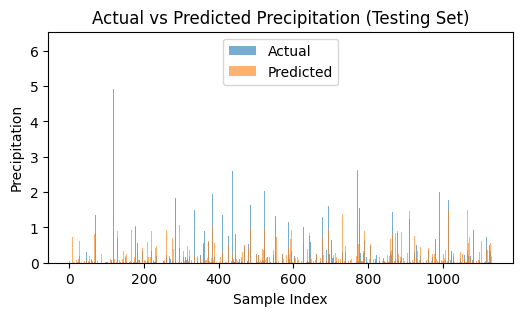

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


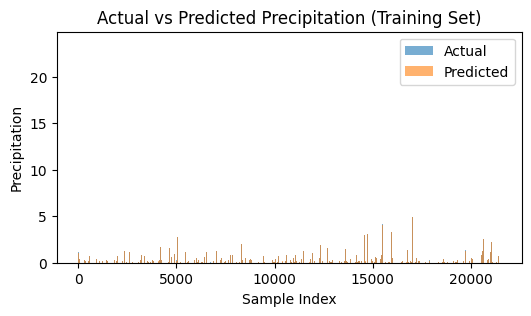

In [19]:
evaluate_model(final_model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)

XGBOOST with l1 l2

[0]	validation_0-rmse:0.84985
[1]	validation_0-rmse:0.83233
[2]	validation_0-rmse:0.81185
[3]	validation_0-rmse:0.80304
[4]	validation_0-rmse:0.78739
[5]	validation_0-rmse:0.77346
[6]	validation_0-rmse:0.76480
[7]	validation_0-rmse:0.75469
[8]	validation_0-rmse:0.74730
[9]	validation_0-rmse:0.74242
[10]	validation_0-rmse:0.73870
[11]	validation_0-rmse:0.73820
[12]	validation_0-rmse:0.73173
[13]	validation_0-rmse:0.72483
[14]	validation_0-rmse:0.72367
[15]	validation_0-rmse:0.72222
[16]	validation_0-rmse:0.72119
[17]	validation_0-rmse:0.71849
[18]	validation_0-rmse:0.71772
[19]	validation_0-rmse:0.71926
[20]	validation_0-rmse:0.71939
[21]	validation_0-rmse:0.71928
[22]	validation_0-rmse:0.71832
[23]	validation_0-rmse:0.71798
[24]	validation_0-rmse:0.71576
[25]	validation_0-rmse:0.71459
[26]	validation_0-rmse:0.71597
[27]	validation_0-rmse:0.71590
[28]	validation_0-rmse:0.71380
[29]	validation_0-rmse:0.70497
[30]	validation_0-rmse:0.70381
[31]	validation_0-rmse:0.70294
[32]	validation_0-

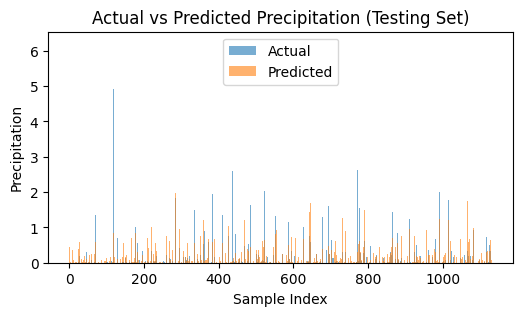

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


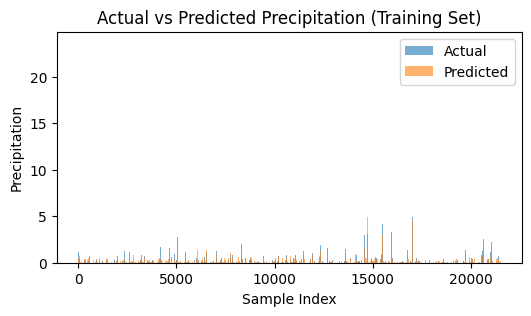

In [37]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# Splitting the data for validation
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train_scaled, y_train_scaled, test_size=0.2, random_state=450)

# Define the model with regularization and early stopping
final_model = XGBRegressor(
    colsample_bytree=0.3,
    learning_rate=0.1,
    max_depth=5,
    n_estimators=500,  # Reduced number of trees
    subsample=0.5,
    reg_alpha=0.75,      # L1 regularization (can be tuned further)
    reg_lambda=0.75,     # L2 regularization (can be tuned further)
    random_state=450
)

# Fit the model with early stopping
final_model.fit(
    X_train_split,
    y_train_split.ravel(),
    eval_set=[(X_val_split, y_val_split)],
    verbose=True
)

# Evaluate the model on training and testing data
evaluate_model(final_model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)


*RAndomforest*

In [38]:
from sklearn.ensemble import RandomForestRegressor
final_model = RandomForestRegressor(
    max_depth=30,
    max_features='log2',
    min_samples_leaf=4,
    min_samples_split=10,
    n_estimators=100,
    random_state=41
)

# Fit the model
final_model.fit(X_train_scaled, y_train_scaled.ravel())

RandomForestRegressor(max_depth=30, max_features='log2', min_samples_leaf=4,
                      min_samples_split=10, random_state=41)

Number of negative values in y_pred_test: 3 and in train 98
Number of negative values after in y_pred_test: 0 and in train 0
Training MSE: 0.17, Training MAE: 0.15
Testing MSE: 0.21, Testing MAE: 0.20


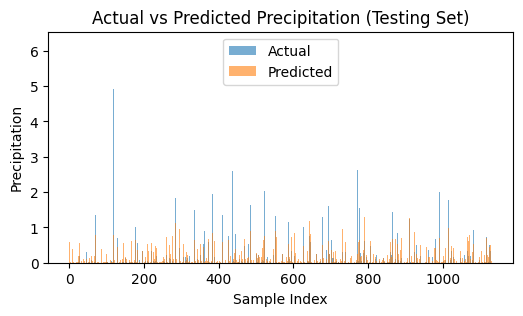

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


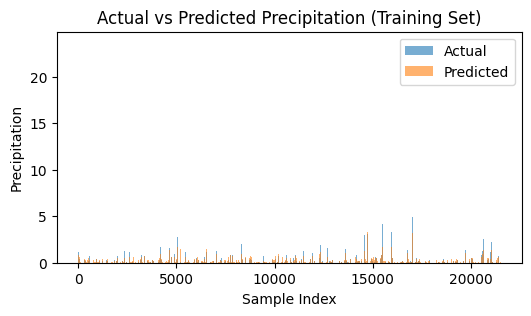

In [39]:
evaluate_model(final_model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)

KNN

In [40]:
from sklearn.neighbors import KNeighborsRegressor

final_model = KNeighborsRegressor(n_neighbors=3)  # You can adjust n_neighbors
final_model.fit(X_train_scaled, y_train_scaled.ravel())

KNeighborsRegressor(n_neighbors=3)

Number of negative values in y_pred_test: 0 and in train 0
Number of negative values after in y_pred_test: 0 and in train 0
Training MSE: 0.08, Training MAE: 0.11
Testing MSE: 0.17, Testing MAE: 0.16


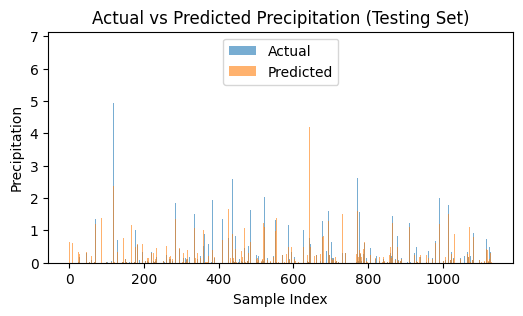

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


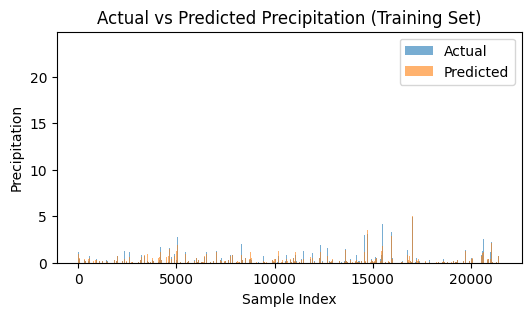

In [41]:
evaluate_model(final_model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)

SVM

In [42]:
from sklearn.svm import SVR

final_model = SVR(
    kernel='rbf',          # Radial basis function kernel
    C=1.0,                 # Regularization parameter
    epsilon=0.1            # Epsilon in the epsilon-SVR model
)
final_model.fit(X_train_scaled, y_train_scaled.ravel())


SVR()

Number of negative values in y_pred_test: 14 and in train 219
Number of negative values after in y_pred_test: 0 and in train 0
Training MSE: 0.50, Training MAE: 0.23
Testing MSE: 0.29, Testing MAE: 0.21


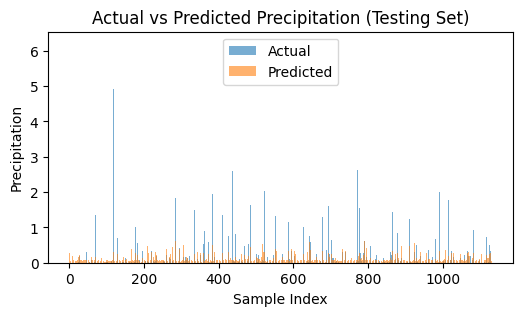

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


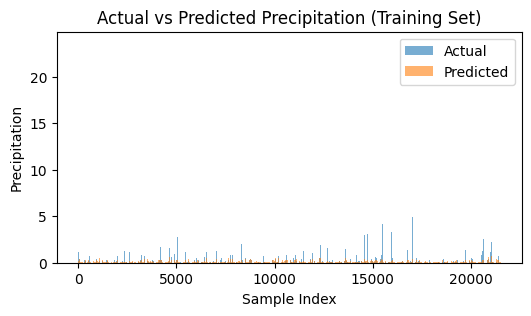

In [43]:
evaluate_model(final_model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)

Lightgbm

In [44]:
import lightgbm as lgb

final_model = lgb.LGBMRegressor(
    boosting_type='gbdt',
    objective='regression',
    num_leaves=31,
    learning_rate=0.1,
    n_estimators=100
)
final_model.fit(X_train_scaled, y_train_scaled.ravel())


/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007626 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9114
[LightGBM] [Info] Number of data points in the train set: 21512, number of used features: 36
[LightGBM] [Info] Start training from score 0.000000


LGBMRegressor(objective='regression')

Number of negative values in y_pred_test: 62 and in train 1216
Number of negative values after in y_pred_test: 0 and in train 0
Training MSE: 0.16, Training MAE: 0.19
Testing MSE: 0.21, Testing MAE: 0.21


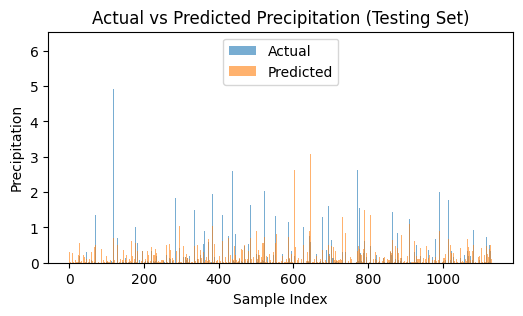

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


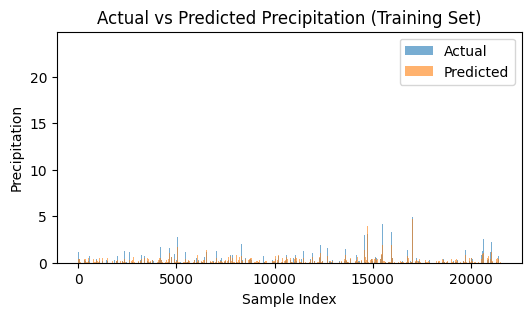

In [45]:
evaluate_model(final_model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)

 Feedforward Neural Network

In [46]:
from sklearn.neural_network import MLPRegressor

final_model = MLPRegressor(
    hidden_layer_sizes=(1000,),   # Single hidden layer with 100 neurons
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    max_iter=500
)
final_model.fit(X_train_scaled, y_train_scaled.ravel())


MLPRegressor(hidden_layer_sizes=(1000,), learning_rate='adaptive', max_iter=500)

Number of negative values in y_pred_test: 315 and in train 5361
Number of negative values after in y_pred_test: 0 and in train 0
Training MSE: 0.26, Training MAE: 0.25
Testing MSE: 0.25, Testing MAE: 0.25


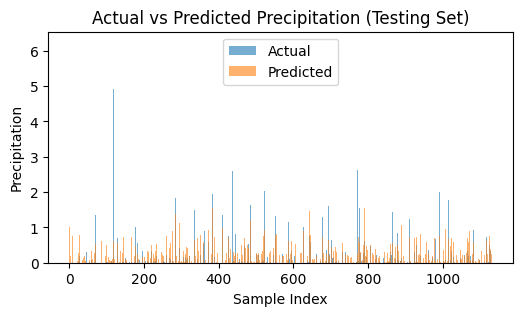

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


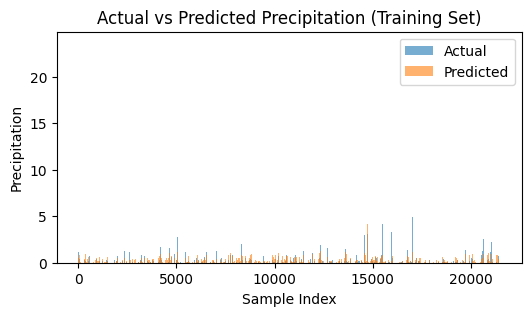

In [47]:
evaluate_model(final_model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)

Decision Tree

In [48]:
from sklearn.tree import DecisionTreeRegressor

final_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=4,
    random_state=42
)
final_model.fit(X_train_scaled, y_train_scaled.ravel())


DecisionTreeRegressor(max_depth=10, min_samples_leaf=4, min_samples_split=5,
                      random_state=42)

Number of negative values in y_pred_test: 2 and in train 28
Number of negative values after in y_pred_test: 0 and in train 0
Training MSE: 0.24, Training MAE: 0.22
Testing MSE: 0.30, Testing MAE: 0.23


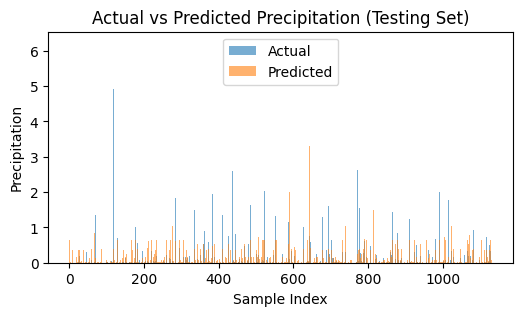

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


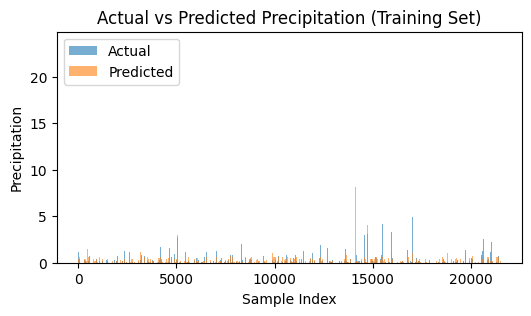

In [49]:
evaluate_model(final_model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)

Stacking ensable

In [50]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

base_models = [
    ('xgb', XGBRegressor(
        colsample_bytree=0.3,
        learning_rate=0.1,
        max_depth=3,
        n_estimators=300,
        subsample=0.5,
        random_state=45
    )),
    ('rf', RandomForestRegressor(
        max_depth=30,
        max_features='log2',
        min_samples_leaf=4,
        min_samples_split=10,
        n_estimators=100,
        random_state=41
    ))
]

final_model = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge(),
    cv=5
)
final_model.fit(X_train_scaled, y_train_scaled.ravel())


StackingRegressor(cv=5,
                  estimators=[('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.3, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learnin...
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=45, ...)),
                              ('rf',
                               RandomForestRegressor(max_depth=30,
                                                     max_features='log2',
                                                     min_samples_leaf=4,
                                                     min_samples_split=10,
                                                     random_state=41))],
                  final_estimator=Ridge())

Number of negative values in y_pred_test: 435 and in train 7686
Number of negative values after in y_pred_test: 0 and in train 0
Training MSE: 0.15, Training MAE: 0.17
Testing MSE: 0.21, Testing MAE: 0.20


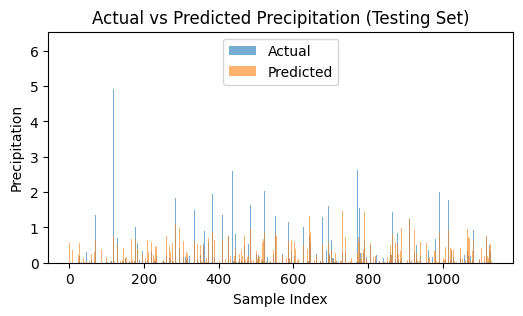

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


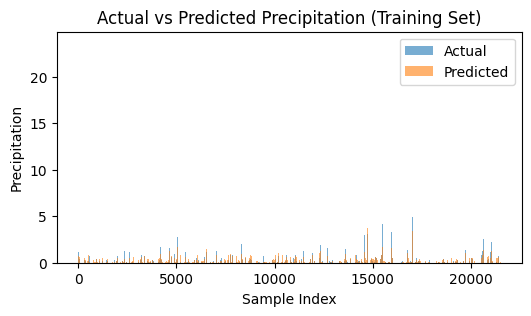

In [51]:
evaluate_model(final_model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)